# Strength / CRSS prediction notebook

This notebook computes the screw-controlled strength in BCC random alloys based on Maresca/Curtin/Ghafarollahi theory, and saves the outputs as CSV and PNG.

In [ ]:
import os

if not os.path.exists("strength_prediction.py"):
    !git clone https://github.com/alirezaghafarollahi2/ScrewTheory.git
from ScrewTheory.strength_prediction import ModelParameters, screw_strength_prediction

## User inputs
Set: 
- `a0: lattice constant (Angstrom)`
- `Ek: kink formation energy (eV)`
- `DEp: solute/screw interaction energy parameter (eV)`
- `Ev: vacancy formation energy (eV)`
- `Esi: interstitial formation energy (eV)`
- `epsilon_0_dot: reference strain rate (/s)`
- `epsilon_dot: experimental strain rate (/s)`
- `wk: kink width (b)`

Also set:
- `CRSS_SIGMAY` to `"SIGMAY" for yield stress prediction` or `"CRSS" for critical resolved shear stress prediction`
- `max_T` in K
- `T_interval` in K
- output file names if needed

The defaults are:
- `CRSS_SIGMAY = "SIGMAY"`
- `max_T = 1000`
- `T_interval = 50`
- `csv_output_name = "my_prediction.csv"`
- `png_output_name = "my_prediction.png"`


In [13]:
CRSS_SIGMAY = "CRSS"        # allowed values: "CRSS" or "SIGMAY"
max_T = 1000                    # K
T_interval = 50                 # K
csv_output_name = "my_prediction.csv"
png_output_name = "my_prediction.png"

# Enter the model parameters here
params = ModelParameters(
    a0=3.3331, # lattice constant
    Ek=0.58425, # kink formation energy (eV)
    DEp=0.100989, # solute/screw interaction energy parameter (eV)
    Ev=2.4193, # vacancy formation energy (eV)
    Esi=4.75695, # interstitial formation energy (eV) 
    epsilon_0_dot=10000, # reference strain rate
    epsilon_dot=0.001, # experimental strain rate
    wk=10, # kink width (b units)
    stress_convert_factor=160218,  
    sigma_factor=2.74,
)

## Run prediction

In [14]:
df = screw_strength_prediction(
    CRSS_SIGMAY=CRSS_SIGMAY,
    max_T=max_T,
    T_interval=T_interval,
    csv_output_name=csv_output_name,
    png_output_name=png_output_name,
    params=params,
)

df

zeta_c/b: 39.25601507627529
Saved CSV: my_prediction.csv
Saved PNG: my_prediction.png


,Temperature (K),CRSS (MPa)
0,0.0,632.406368
1,50.0,494.266589
2,100.0,399.641012
3,150.0,329.593527
4,200.0,275.504392
5,250.0,232.382784
6,300.0,197.128981
7,350.0,169.633814
8,400.0,144.727235
9,450.0,119.895329


## Show saved plot

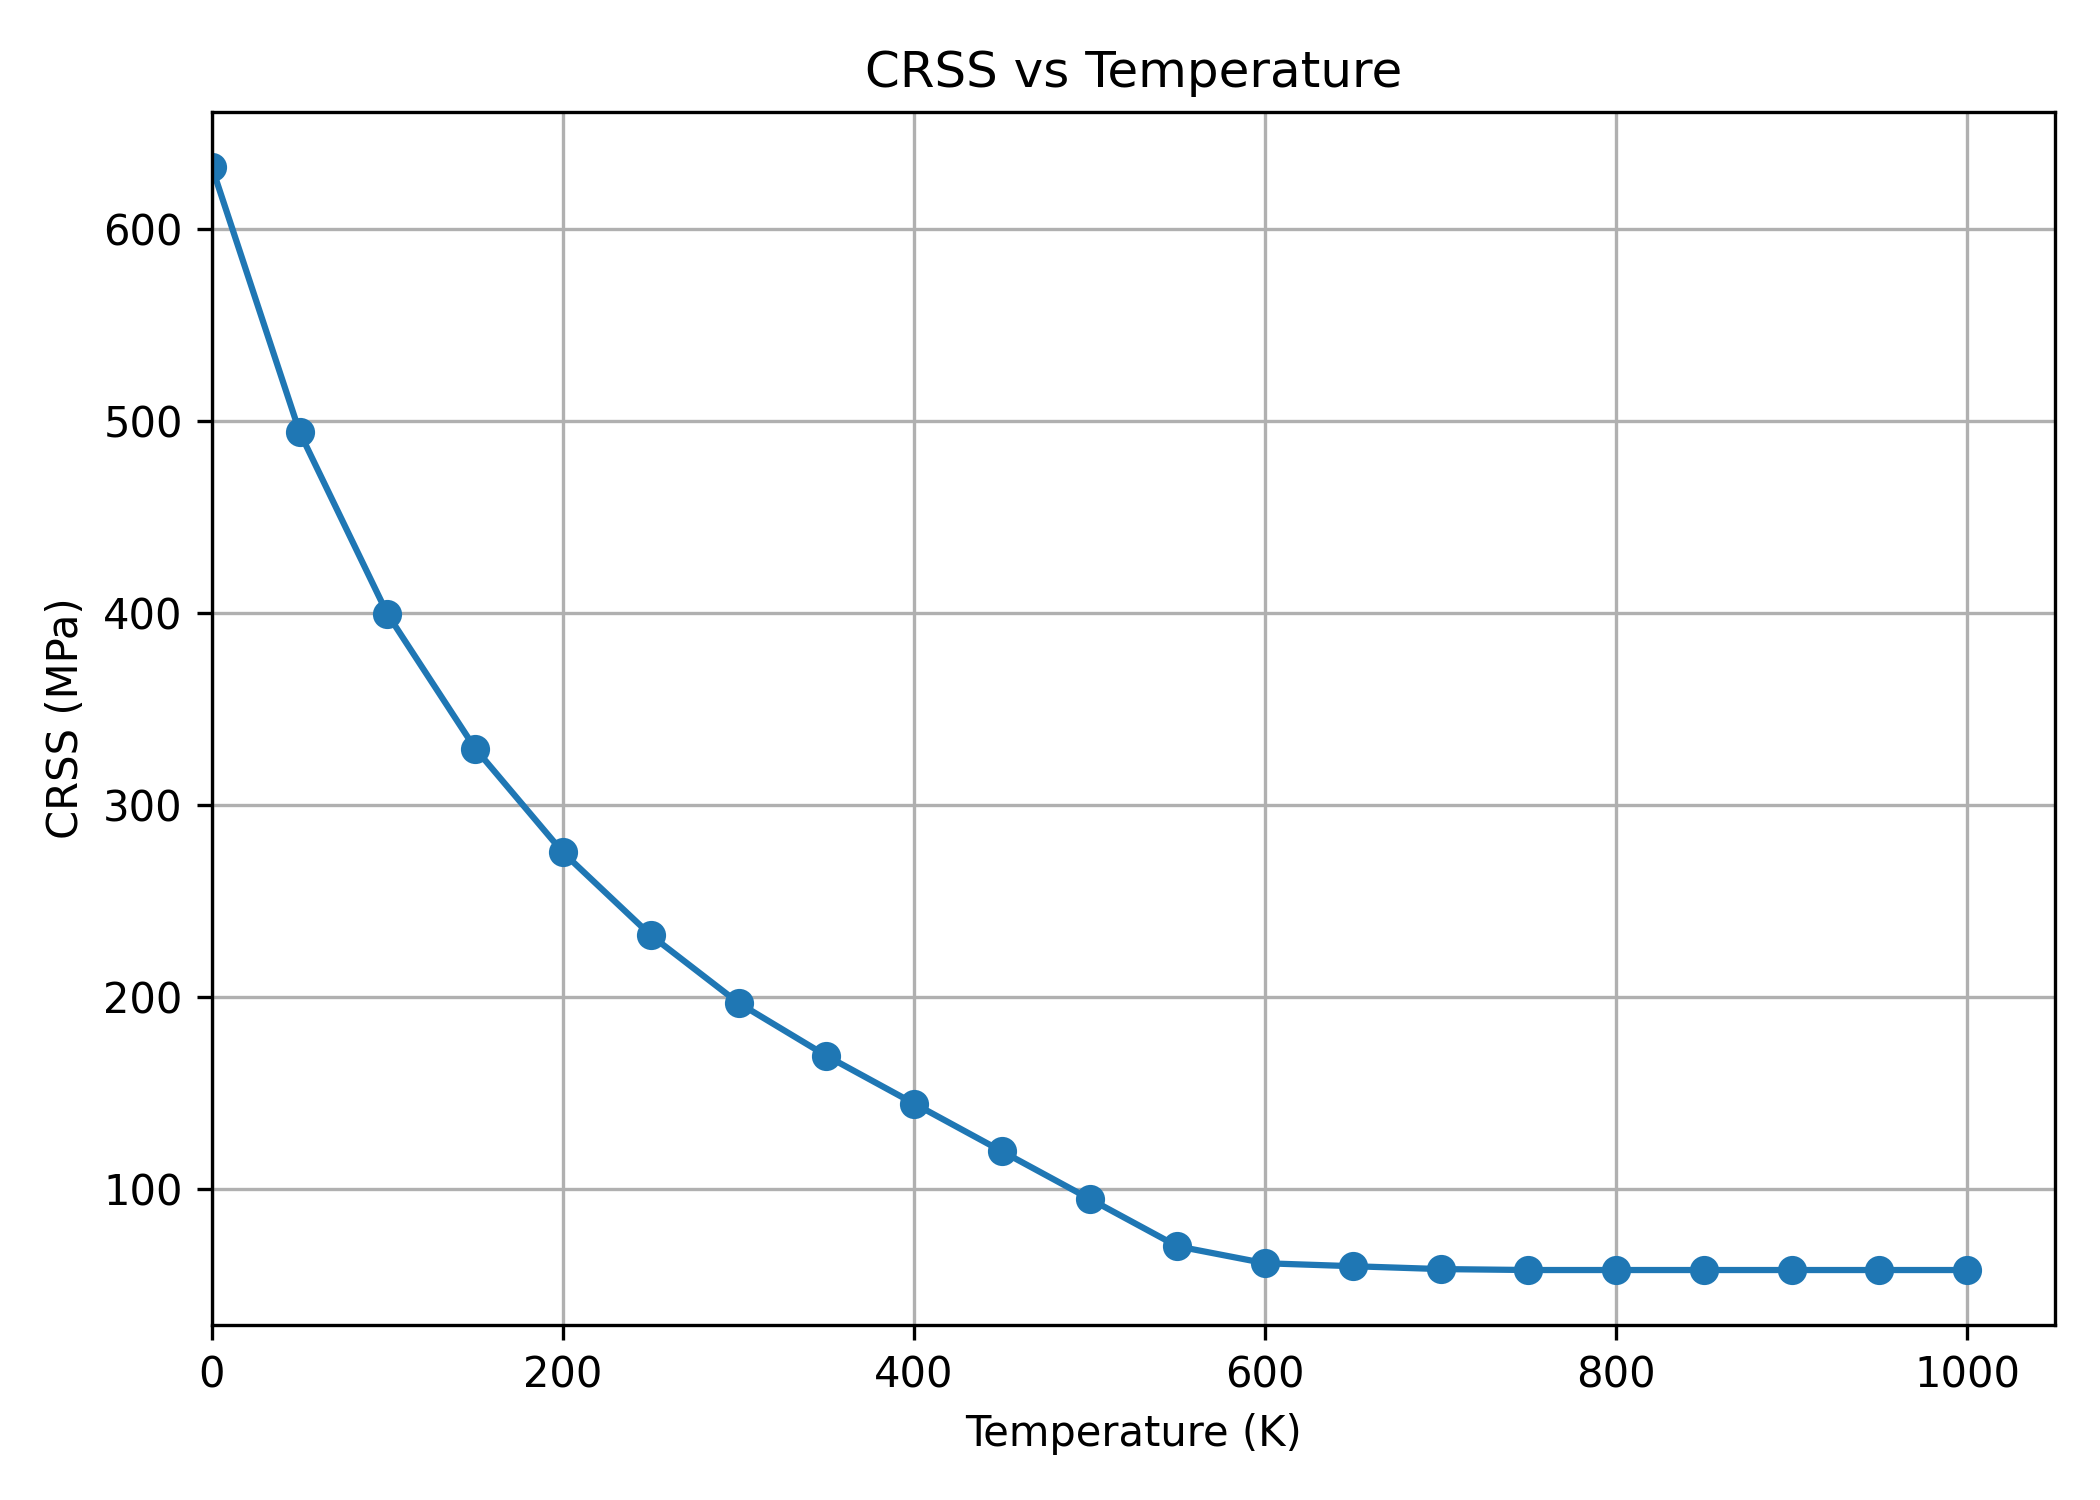

In [15]:
from IPython.display import Image, display

display(Image(filename=png_output_name))